In [38]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from scipy.io import loadmat  ### use this to load .mat files

In [39]:
A = loadmat('VORTALL.mat')  ### load the .mat file
print(A.keys())  ### print the keys of the dictionary to see what is inside
K = A['VORTALL']  ### extract the variable from the dictionary 
print(K.shape)
print(K)  ### print the variable to see what it looks like


dict_keys(['__header__', '__version__', '__globals__', 'VORTALL'])
(89351, 151)
[[-5.92220e-15 -4.68318e-15 -2.94902e-15 ... -9.62025e-15 -8.86421e-15
  -7.27853e-15]
 [-6.01624e-15 -4.61205e-15 -2.58238e-15 ... -9.57891e-15 -8.89550e-15
  -7.31406e-15]
 [-5.92116e-15 -4.68413e-15 -2.50956e-15 ... -9.98390e-15 -8.95430e-15
  -7.50686e-15]
 ...
 [-1.47386e-02 -5.92327e-03 -1.69510e-03 ... -3.54696e-02 -3.64824e-02
  -2.84128e-02]
 [-1.36956e-02 -5.31169e-03 -1.47472e-03 ... -4.07780e-02 -3.80910e-02
  -2.78294e-02]
 [-1.26353e-02 -4.73980e-03 -1.27796e-03 ... -4.49435e-02 -3.89362e-02
  -2.69284e-02]]


In [52]:
frame1 = K[:,0].reshape(199,449, order='F')
print(frame1.shape )



(199, 449)


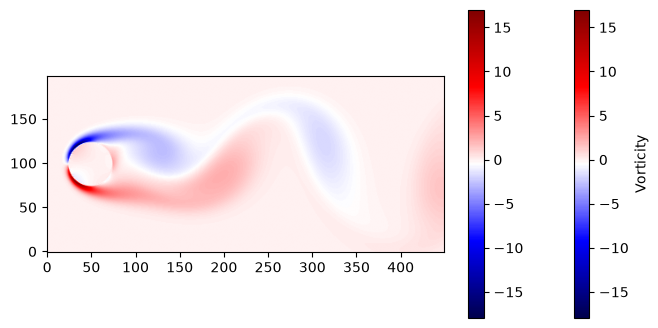

In [59]:
plt.figure(figsize=(8,4))
plt.imshow(frame1, cmap='seismic', origin='lower')
plt.colorbar(label='Vorticity')
plt.colorbar()
plt.show()

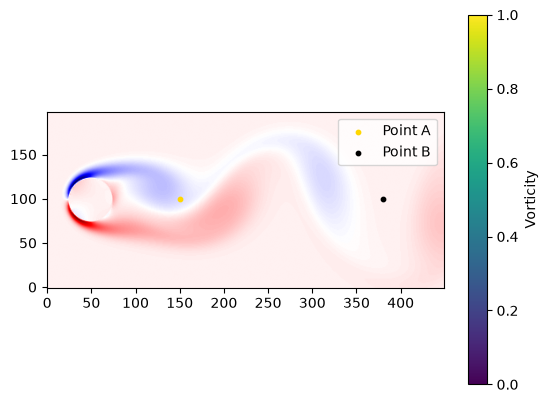

In [74]:
plt.Figure(figsize=(8,4))
plt.imshow(frame1,cmap='seismic', origin='lower')
plt.scatter(150,100,color='gold',s=10,label='Point A')
plt.scatter(380,100,color='Black',s=10,label='Point B')
plt.legend()
plt.colorbar(label='Vorticity')
plt.show()
plt.show()

In [71]:
K3 =K.reshape(199,449,151,order='F')
K3.shape

(199, 449, 151)

In [76]:
ptA=K3[100,150,:]
ptB=K3[100,380,:]
t = np.arange(151)*0.1

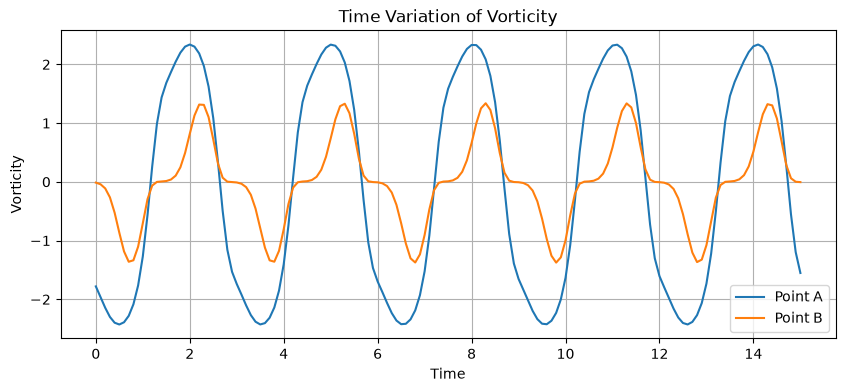

In [77]:
plt.figure(figsize=(10,4))

plt.plot(t,ptA,label='Point A')
plt.plot(t,ptB,label='Point B')

plt.xlabel('Time')
plt.ylabel('Vorticity')
plt.title('Time Variation of Vorticity')
plt.legend()
plt.grid(True)

plt.show()

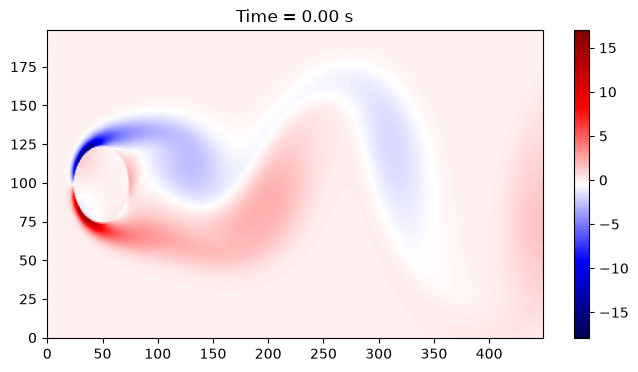

In [89]:


fig, ax = plt.subplots(figsize=(8,4))

frame = K[:, 0].reshape(199, 449, order='F')

im = ax.imshow(frame,
               cmap='seismic',
               origin='lower',
               aspect='auto')

plt.colorbar(im, ax=ax)

for i in range(151):

    frame = K[:, i].reshape(199, 449, order='F')

    im.set_data(frame)        # Update only the image
    time = i * 0.1
    ax.set_title("Time = {:.2f} s".format(time))

    plt.pause(0.01)

plt.show()


In [94]:
U , S ,VT = np.linalg.svd(K, full_matrices=False)
print(U)
print(S)
print(VT)
print(U.shape)
print(S.shape)
print(VT.shape)

[[-3.50303365e-15  1.66384906e-15  4.45185351e-16 ... -1.21488534e-09
  -1.30080988e-09  3.18474677e-10]
 [-3.91006441e-16 -1.12083047e-15  3.14331462e-15 ...  5.29882064e-11
  -1.08318801e-10 -6.68777446e-11]
 [ 1.43411864e-16  3.15111667e-16 -1.58384919e-16 ...  2.95678795e-11
   2.91260815e-10  2.11805562e-11]
 ...
 [-2.56500761e-04 -5.12704128e-04 -6.26831118e-04 ... -6.67749883e-04
  -9.97601466e-04 -4.08591517e-05]
 [-2.58856999e-04 -4.70096814e-04 -6.53903396e-04 ...  3.40916954e-04
  -6.45282160e-04  7.11504923e-04]
 [-2.60204012e-04 -4.29151823e-04 -6.77424317e-04 ... -2.77910110e-04
   4.22141253e-04  1.77872544e-04]]
[3.57580378e+03 1.29817019e+03 1.27964570e+03 4.66755931e+02
 4.63816628e+02 3.65751031e+02 3.58025504e+02 1.45996593e+02
 1.45112347e+02 7.71372249e+01 7.68813214e+01 3.74530672e+01
 3.73441960e+01 2.18241407e+01 2.17577429e+01 1.24266004e+01
 1.23655073e+01 6.91246851e+00 6.88767488e+00 3.60453697e+00
 3.59081406e+00 1.91946271e+00 1.91508716e+00 9.87731489e-0

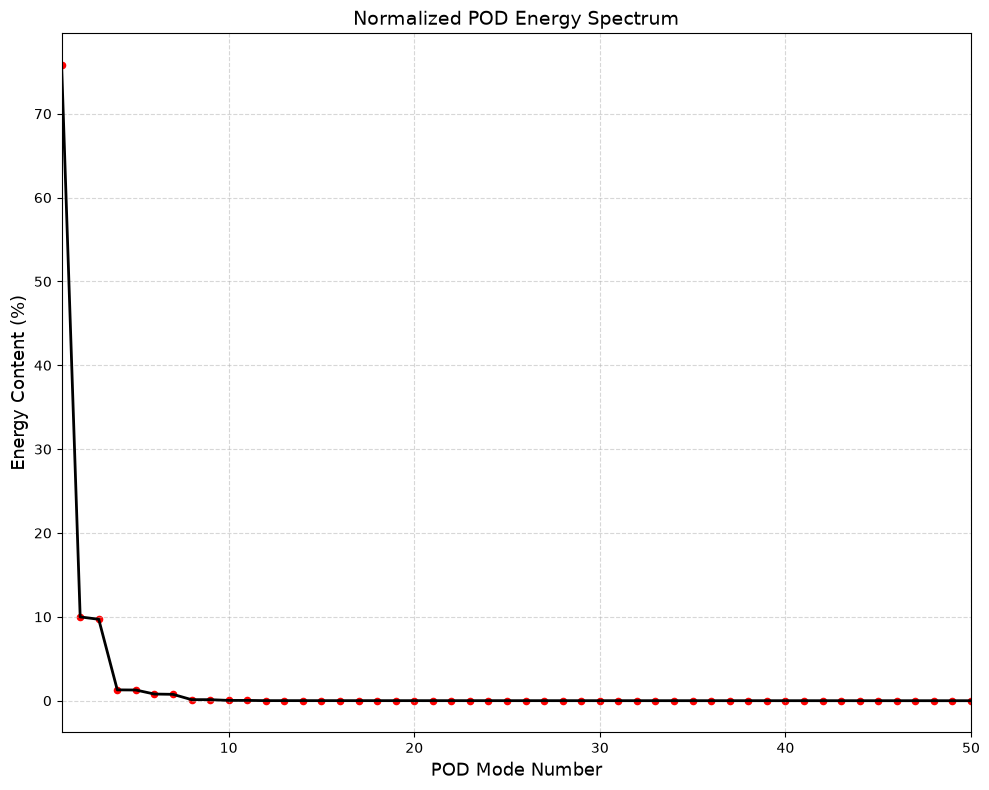

In [ ]:
## E is propotional to sigma^2
E = S**2
E.shape
E_norm = E/np.sum(E)
mode =np.arange(1,len(S+1))


# POD Energy
energy = S**2
energy = energy / np.sum(energy)

mode = np.arange(1, len(S)+1)

plt.figure(figsize=(10,8))

plt.plot(mode, energy*100,color='black', linewidth=2)

plt.scatter(mode, energy*100, color='red', s=20)

plt.xlim(1,50)        # Show first 50 modes

plt.xlabel('POD Mode Number', fontsize=13)
plt.ylabel('Energy Content (%)', fontsize=13)
plt.title('Normalized POD Energy Spectrum', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

(199, 449)


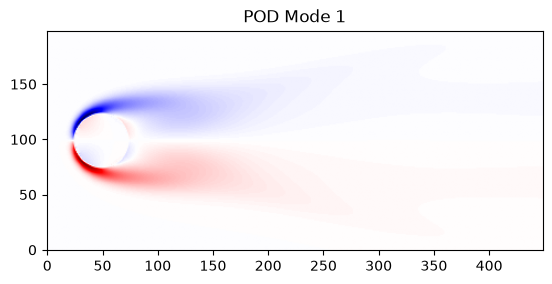

In [121]:
mode1=U[:,0].reshape(199,449,order='F')
print(mode1.shape)
plt.Figure(figsize=(10,6))
plt.imshow(mode1,cmap='seismic', origin='lower')
plt.title("POD Mode 1")
plt.show()

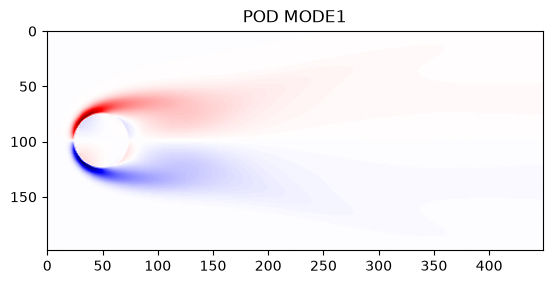

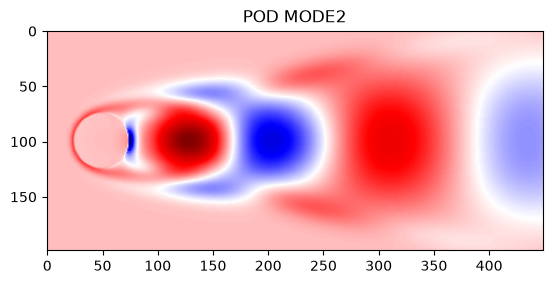

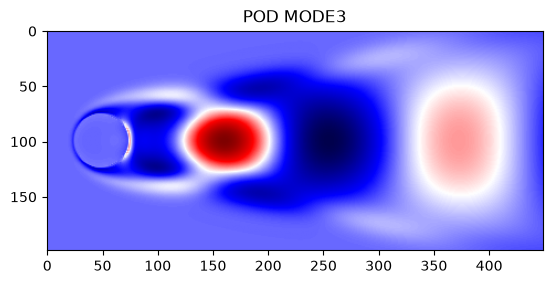

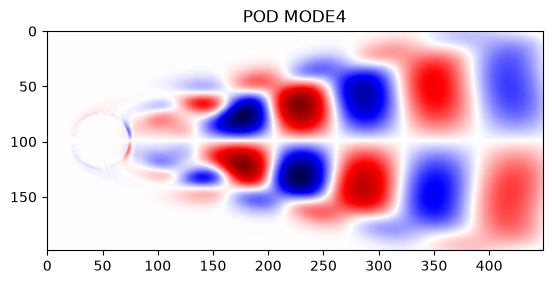

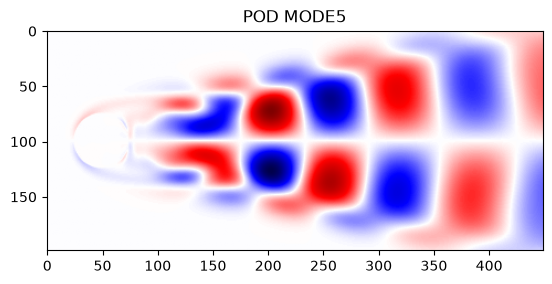

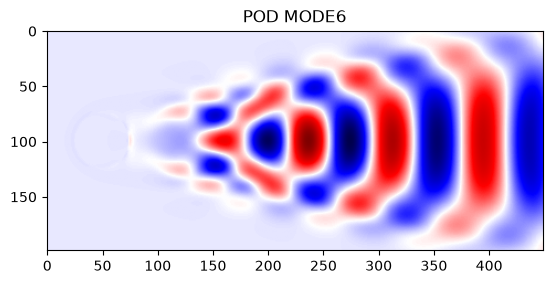

In [129]:


for i in range(6):
    mode =U[:,i].reshape(199,449,order='F')
    plt.Figure(figsize=(10,8))
    plt.imshow(mode,cmap='seismic')
    plt.colorbar
    plt.title(f'POD MODE{i+1}')
    plt.show()